In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df  = pd.read_csv('../Dataset/resumeJD2_pairs.csv', engine='python', on_bad_lines='skip')
df.head()

,resume_text,job_description,match_score,match_label
0,Name: Kritika Shah || Email: kritika.shah55@gm...,Job Title: FP&A Analyst || Company: Amazon | L...,0.55,partial match
1,Name: Arjun Verma || Email: arjun.verma70@gmai...,Job Title: Design Lead || Company: Paytm | Loc...,0.27,no match
2,Name: Manish Bhatt || Email: manish.bhatt89@gm...,Job Title: Security Analyst || Company: KPMG |...,0.46,partial match
3,Name: Natasha Sharma || Email: natasha.sharma7...,Job Title: Sales Director || Company: Ola | Lo...,0.09,no match
4,Name: Kavya Agarwal || Email: kavya.agarwal75@...,Job Title: Business Development Manager || Com...,0.66,partial match


In [30]:
# Remove special characters from a single column
df['resume_text'] = df['resume_text'].str.replace(r'[^a-zA-Z0-9\s\+\#\.\-\/]', '', regex=True)

# Do the same for job_description
df['job_description'] = df['job_description'].str.replace(r'[^a-zA-Z0-9\s\+\#\.\-\/]','', regex=True)


In [31]:
df['resume_text_len'] = df['resume_text'].apply(lambda x : len(x.split()))
df['jd_length'] = df['job_description'].apply(lambda x : len(x.split()))

# df['match_label'] = df['match_label'].map({'no match' : 0.0, 'partial match' : 0.5, 'match' : 1})
df.head(10)


,resume_text,job_description,match_score,match_label,resume_text_len,jd_length
0,Name Kritika Shah Email kritika.shah55gmail.c...,Job Title FPA Analyst Company Amazon Locatio...,0.55,partial match,157,154
1,Name Arjun Verma Email arjun.verma70gmail.com...,Job Title Design Lead Company Paytm Location...,0.27,no match,173,159
2,Name Manish Bhatt Email manish.bhatt89gmail.c...,Job Title Security Analyst Company KPMG Loca...,0.46,partial match,162,150
3,Name Natasha Sharma Email natasha.sharma76gma...,Job Title Sales Director Company Ola Locatio...,0.09,no match,151,165
4,Name Kavya Agarwal Email kavya.agarwal75gmail...,Job Title Business Development Manager Compan...,0.66,partial match,166,164
5,Name Divya Bhatt Email divya.bhatt72gmail.com...,Job Title Senior Data Scientist Company EY L...,0.11,no match,165,158
6,Name Varun Naidu Email varun.naidu97gmail.com...,Job Title Investment Analyst Company upGrad ...,0.95,match,157,152
7,Name Vikram Singh Email vikram.singh43gmail.c...,Job Title Financial Analyst Company Zoho Loc...,0.17,no match,168,154
8,Name Ananya Joshi Email ananya.joshi19gmail.c...,Job Title Group Product Manager Company Zerod...,0.75,match,170,159
9,Name Rishabh Banerjee Email rishabh.banerjee7...,Job Title Recruiter Company Flipkart Locatio...,0.94,match,159,161


In [32]:
df.describe()

,match_score,resume_text_len,jd_length
count,500.000000,500.000000,500.000000
mean,0.529720,160.970000,157.088000
std,0.283882,7.079077,5.462227
min,0.050000,142.000000,144.000000
25%,0.280000,156.000000,153.000000
50%,0.540000,161.000000,157.000000
75%,0.790000,165.000000,161.000000
max,0.980000,184.000000,172.000000


In [33]:
df.columns

Index(['resume_text', 'job_description', 'match_score', 'match_label',
       'resume_text_len', 'jd_length'],
      dtype='object')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      500 non-null    object 
 1   job_description  500 non-null    object 
 2   match_score      500 non-null    float64
 3   match_label      500 non-null    object 
 4   resume_text_len  500 non-null    int64  
 5   jd_length        500 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 23.6+ KB


In [35]:
df.describe(include='object')

,resume_text,job_description,match_label
count,500,500,500
unique,500,500,3
top,Name Shreya Saxena Email shreya.saxena63gmail...,Job Title Credit Analyst Company CRED Locati...,no match
freq,1,1,190


In [36]:

# Check for the missing values
print("Missing Values Analysis:")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
print(missing_df)
print(f"\nTotal missing values: {missing.sum()}")

Missing Values Analysis:
                 Missing_Count  Percentage
resume_text                  0         0.0
job_description              0         0.0
match_score                  0         0.0
match_label                  0         0.0
resume_text_len              0         0.0
jd_length                    0         0.0

Total missing values: 0


In [37]:
full_dupes = df.duplicated().sum()
print(f"Full duplicate rows: {full_dupes}")

Full duplicate rows: 0


In [38]:
pair_dupes = df.duplicated(subset=['resume_text', 'job_description']).sum()
print(f"Duplicate resume+JD pairs: {pair_dupes}")

Duplicate resume+JD pairs: 0


In [39]:
print(f"Total rows:          {len(df)}")
print(f"Unique resumes:      {df['resume_text'].nunique()}")
print(f"Unique JDs:          {df['job_description'].nunique()}")
print(f"Unique resume+JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")

Total rows:          500
Unique resumes:      500
Unique JDs:          500
Unique resume+JD pairs: 500


In [40]:
print("Unique labels found:")
print(df['match_label'].value_counts())

print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")
print("Distinct values:", df['match_label'].unique())

Unique labels found:
match_label
no match         190
match            158
partial match    152
Name: count, dtype: int64

Expected 3 labels, got: 3 unique values
Distinct values: ['partial match' 'no match' 'match']


In [41]:

print("Score distribution:")
print(df['match_score'].describe())
print()

# Scores must be between 0.0 and 1.0 — flag the bad ones
invalid_scores = df[(df['match_score'] < 0) | (df['match_score'] > 1)]
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")
print(invalid_scores[['match_label', 'match_score']])

Score distribution:
count    500.000000
mean       0.529720
std        0.283882
min        0.050000
25%        0.280000
50%        0.540000
75%        0.790000
max        0.980000
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []


In [42]:
print("Score stats per label (after lowercasing):")
print(df.groupby('match_label')['match_score'].describe().round(2))

# Expected:
#   high   → 0.75 – 0.95
#   medium → 0.40 – 0.70
#   low    → 0.05 – 0.35

Score stats per label (after lowercasing):
               count  mean   std   min   25%   50%   75%   max
match_label                                                   
match          158.0  0.86  0.07  0.75  0.80  0.86  0.93  0.98
no match       190.0  0.22  0.10  0.05  0.13  0.22  0.31  0.39
partial match  152.0  0.57  0.10  0.40  0.48  0.58  0.67  0.74


In [43]:
print("Missing values per column:")
print(df.isnull().sum())
print()

# Show the rows with nulls
nulls = df[df.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(nulls)}")
nulls[['match_label', 'match_score']].head(10)

Missing values per column:
resume_text        0
job_description    0
match_score        0
match_label        0
resume_text_len    0
jd_length          0
dtype: int64

Rows with at least one null: 0


,match_label,match_score


In [44]:
print("Missing values per column:")
print(df.isnull().sum())
print()

# Show the rows with nulls
nulls = df[df.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(nulls)}")
nulls[['match_label', 'match_score']].head(10)

Missing values per column:
resume_text        0
job_description    0
match_score        0
match_label        0
resume_text_len    0
jd_length          0
dtype: int64

Rows with at least one null: 0


,match_label,match_score


In [45]:
print("=" * 50)
print("DATA QUALITY REPORT — merged_dataset.csv")
print("=" * 50)
print(f"  Total rows:             {len(df)}")
print(f"  Full duplicates:        {df.duplicated().sum()}")
print(f"  Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")
print(f"  Null resume_text:       {df['resume_text'].isnull().sum()}")
print(f"  Null job_description:   {df['job_description'].isnull().sum()}")
print(f"  Label case variants:    {df['match_label'].nunique()} (expected 3)")
print(f"  Invalid scores (<0/>1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")
print("=" * 50)


DATA QUALITY REPORT — merged_dataset.csv
  Total rows:             500
  Full duplicates:        0
  Duplicate pairs:        0
  Null resume_text:       0
  Null job_description:   0
  Label case variants:    3 (expected 3)
  Invalid scores (<0/>1): 0


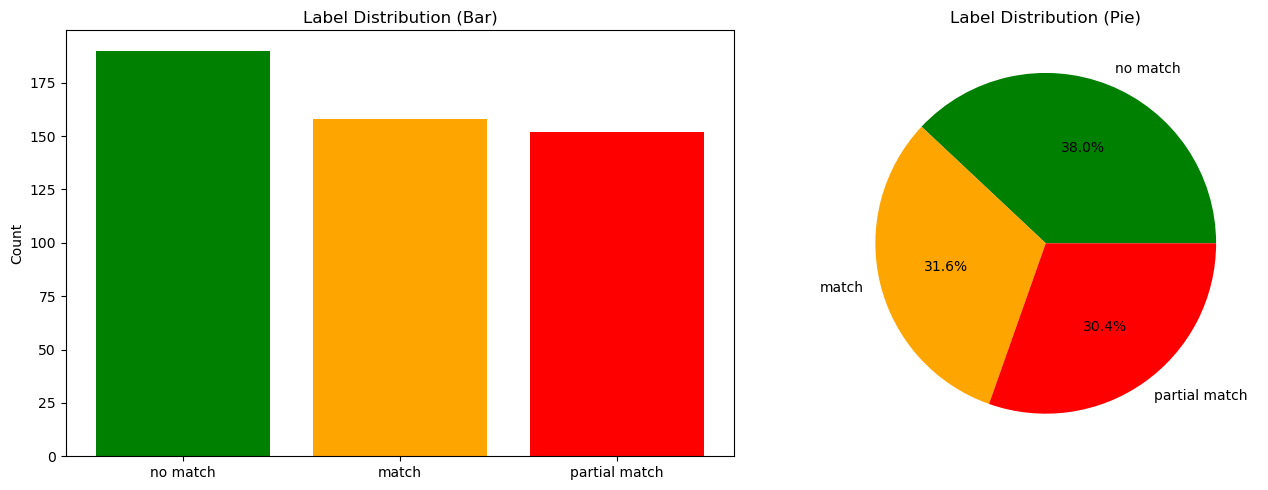

In [46]:
# Pie chart + bar side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['match_label'].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=['green','orange','red'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['green','orange','red'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()

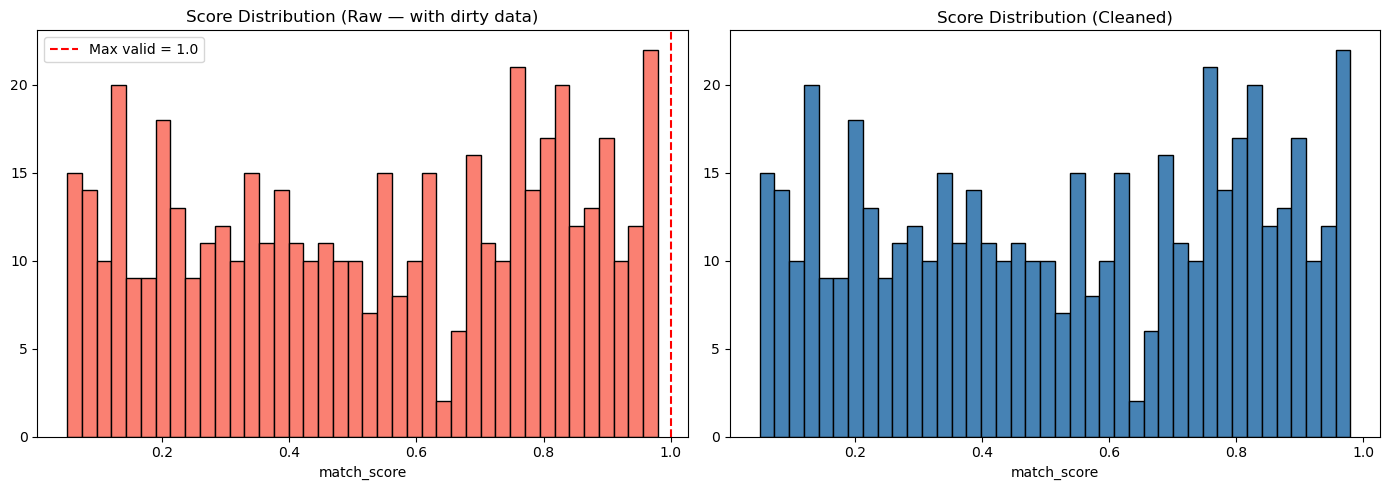

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw — with dirty data)')
axes[0].set_xlabel('match_score')
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# After cleaning
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

plt.tight_layout()
plt.show()

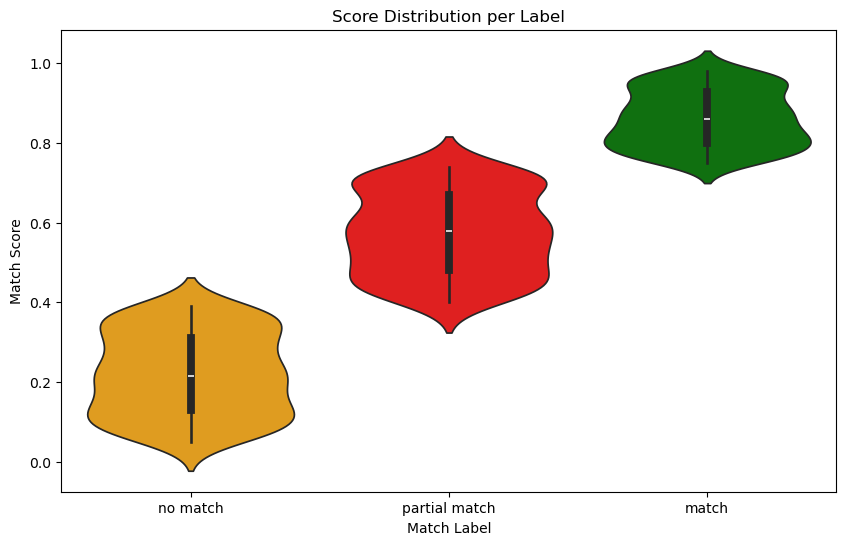

In [48]:
import seaborn as sns

df_plot = df.copy()
df_plot['match_label'] = df_plot['match_label'].str.lower()
df_plot = df_plot[(df_plot['match_score'] >= 0) & (df_plot['match_score'] <= 1)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x='match_label', y='match_score',
               order=['no match','partial match','match'], # Reorder to match default colors if needed, or specify for palette
               palette=['red','orange','green'],
               hue='match_label', legend=False) # Fix: Assign x to hue and set legend=False
plt.title('Score Distribution per Label')
plt.xlabel('Match Label')
plt.ylabel('Match Score')
plt.show()

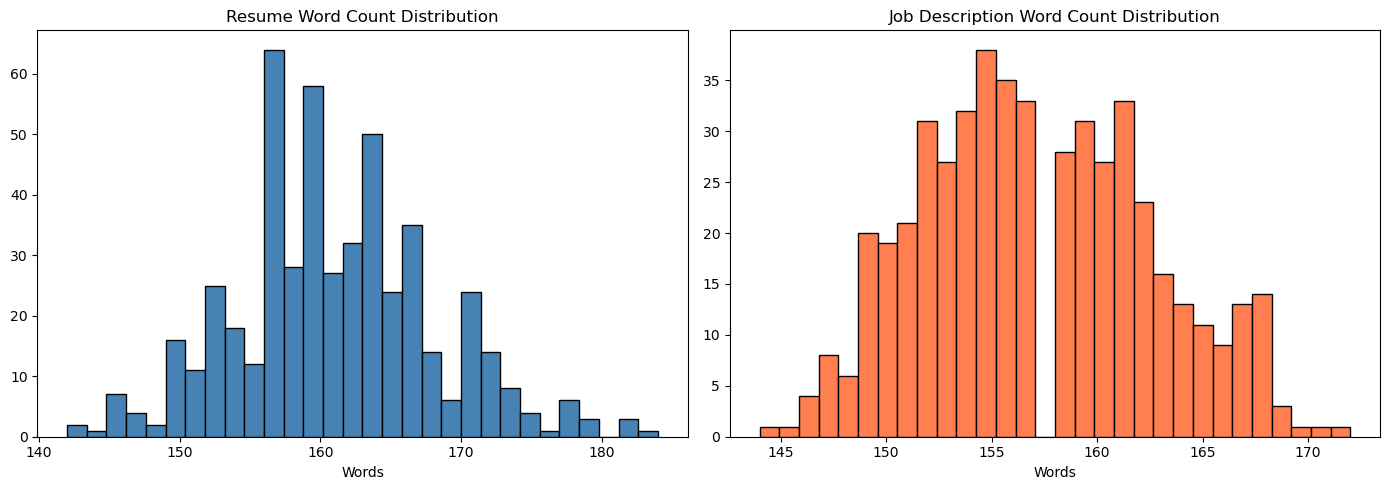

In [49]:
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len']     = df_plot['job_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

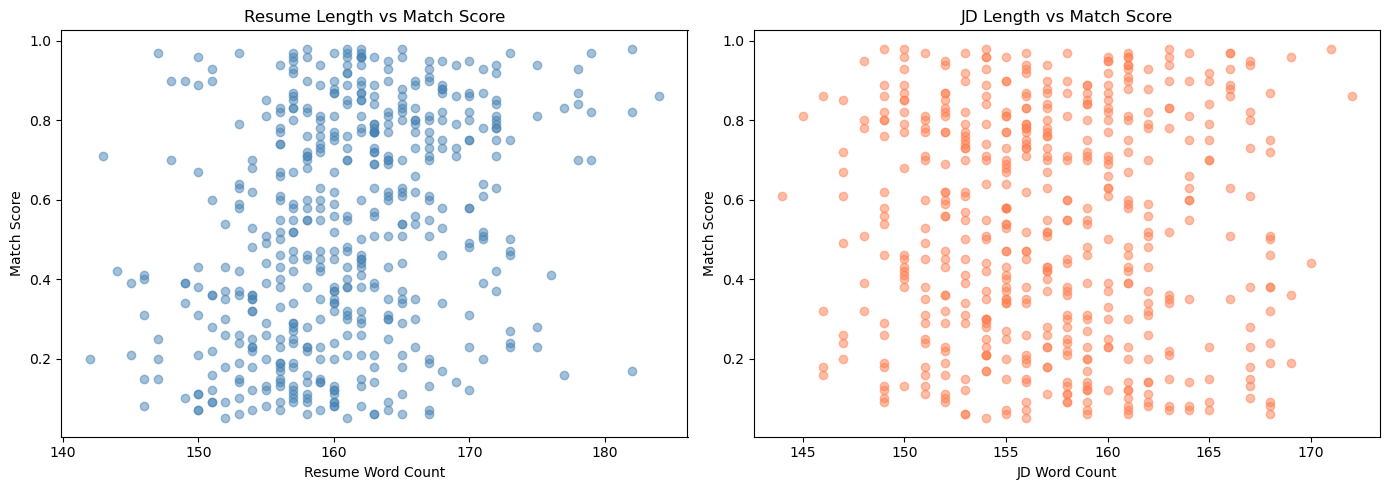

Resume length correlation: 0.311
JD length correlation:     -0.011


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# Actual correlation values
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))

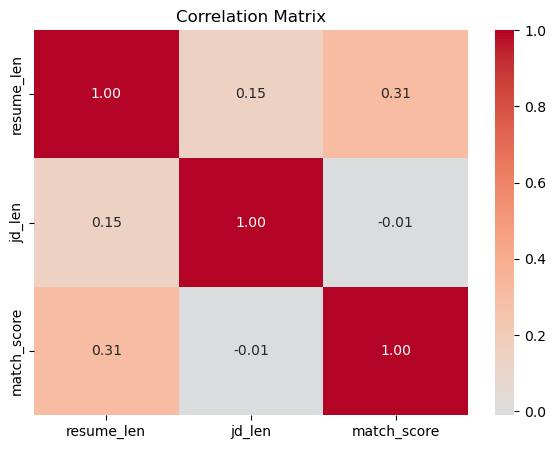

In [51]:

plt.figure(figsize=(7, 5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [52]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


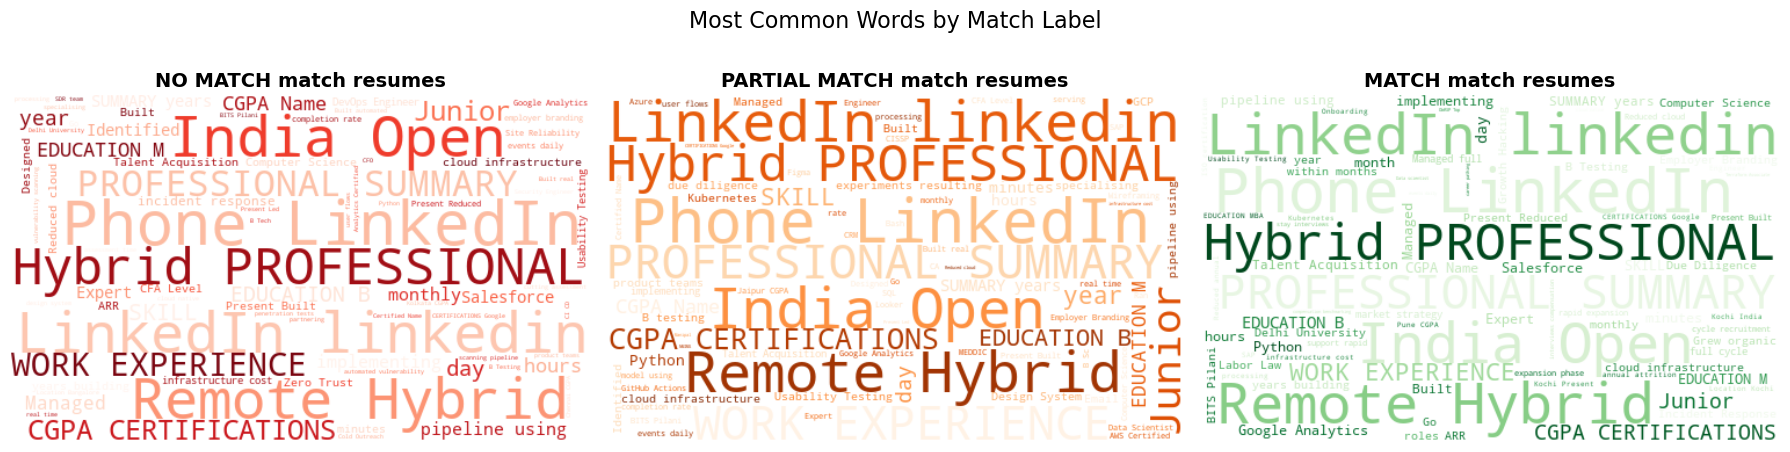

In [53]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels  = ['no match', 'partial match', 'match'] # Corrected labels
colors  = ['Reds', 'Oranges', 'Greens']

for ax, label, cmap in zip(axes, labels, colors):
    text = ' '.join(df_plot[df_plot['match_label'] == label]['resume_text'].dropna())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} match resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()

In [54]:
# Suppose your cleaned DataFrame is called df_clean
df.to_csv("../Dataset/cleaned_dataset.csv", index=False)
